# Layer 4: Entity Resolution — Product Matching

**Goal:** Match the same physical product across stores and assign a unique `product_id`.

**Strategy:** Pre-filter by Brand+Unit+Size, then fuzzy name match (≥80%) within each group.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# --- Premium Global Styling ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   18,
    'axes.labelsize':   12,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})
sns.set_theme(style='whitegrid', font_scale=1.1)
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}
BASE_DIR = Path(os.getcwd()).parent
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz, process
from pathlib import Path
import hashlib, warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'#fafafa','axes.facecolor':'#fafafa','axes.titleweight':'bold','axes.titlesize':16})
sns.set_theme(style='whitegrid')
sns.set_context('talk')
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}

BASE_DIR    = Path(os.getcwd()).parent
DATA_DIR    = BASE_DIR / 'data'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'matched').mkdir(parents=True, exist_ok=True)

INPUT_PATH  = DATA_DIR / 'processed' / 'normalized_data.csv'
OUTPUT_PATH = DATA_DIR / 'matched'   / 'matched_products.csv'
FUZZY_THRESHOLD = 80
print(f'Project root: {BASE_DIR}')

Project root: D:\supermarket-pipeline


## 4.1 — Load Normalized Data

In [2]:
df = pd.read_csv(INPUT_PATH, low_memory=False)
print(f'Loaded {len(df):,} rows | Columns: {list(df.columns)}')
df.head(3)

Loaded 183,792 rows | Columns: ['store_name', 'city', 'product_name_clean', 'brand_clean', 'price_clean', 'size_normalized', 'unit_normalized', 'price_per_unit', 'category_normalized', 'image_url', 'product_url', 'scraped_at']


,store_name,city,product_name_clean,brand_clean,price_clean,size_normalized,unit_normalized,price_per_unit,category_normalized,image_url,product_url,scraped_at
0,Al-Fatah,Faisalabad,aquafina pure drinking water 500ml-carton,Aquafina,540.0,500.0,ml,1.08,Grocery Staples,https://alfatah.pk/cdn/shop/files/AFP-00011558...,https://alfatah.pk/products/aquafina-pure-drin...,2026-03-08T20:17:01.040530
1,Al-Fatah,Faisalabad,aquafina pure drinking water 500 ml,Aquafina,45.0,500.0,ml,0.09,Grocery Staples,https://alfatah.pk/cdn/shop/files/1057363-1.jp...,https://alfatah.pk/products/aquafina-pure-drin...,2026-03-08T20:17:01.040530
2,Al-Fatah,Faisalabad,ff denali water 330 ml,Unknown,0.0,330.0,ml,0.00,Grocery Staples,https://alfatah.pk/cdn/shop/files/180402876961...,https://alfatah.pk/products/ff-denali-water-1-...,2026-03-08T20:17:01.040530


## 4.2 — Create Pre-Filter Match Key

In [3]:
def size_bucket(size):
    if pd.isna(size): return 'unknown'
    return round(float(size) / 50) * 50

df['size_bucket'] = df['size_normalized'].apply(size_bucket)
df['match_key'] = (
    df['brand_clean'].fillna('unknown').str.lower().str.strip() + '|' +
    df['unit_normalized'].fillna('N/A').str.lower() + '|' +
    df['size_bucket'].astype(str)
)
print(f'Unique pre-filter groups: {df["match_key"].nunique():,}')
df[['product_name_clean','brand_clean','size_normalized','unit_normalized','match_key']].head(5)

Unique pre-filter groups: 3,654


,product_name_clean,brand_clean,size_normalized,unit_normalized,match_key
0,aquafina pure drinking water 500ml-carton,Aquafina,500.0,ml,aquafina|ml|500
1,aquafina pure drinking water 500 ml,Aquafina,500.0,ml,aquafina|ml|500
2,ff denali water 330 ml,Unknown,330.0,ml,unknown|ml|350
3,banana(kela) pk dozen,Dozen,NaN,NaN,dozen|n/a|unknown
4,olpers milk full cream 250 ml - pouch carton,Olpers,250.0,ml,olpers|ml|250


## 4.3 — Fuzzy Matching Across Stores

In [4]:
def make_product_id(text):
    return 'P' + hashlib.md5(str(text).encode()).hexdigest()[:8].upper()

def fuzzy_match_group(group_df, threshold=FUZZY_THRESHOLD):
    # Performance Optimization: Use rapidfuzz for significantly faster matching
    names   = group_df['product_name_clean'].fillna('').tolist()
    indices = group_df.index.tolist()
    clusters, assigned = {}, {}
    
    for idx, name in zip(indices, names):
        matched = False
        # Rapidfuzz token_sort_ratio is much faster than fuzzywuzzy
        for canonical, members in clusters.items():
            if fuzz.token_sort_ratio(name, canonical) >= threshold:
                members.append(idx); assigned[idx] = canonical; matched = True; break
        if not matched:
            clusters[name] = [idx]; assigned[idx] = name
    return assigned

print('Running entity resolution (Optimized with rapidfuzz)...')
all_assignments = {}
multi_store_groups = 0
for key, grp in df.groupby('match_key'):
    if grp['store_name'].nunique() > 1:
        multi_store_groups += 1
        all_assignments.update(fuzzy_match_group(grp))
    else:
        for idx in grp.index:
            all_assignments[idx] = grp.at[idx, 'product_name_clean']

df['canonical_name'] = pd.Series(all_assignments)
df['product_id']     = df['canonical_name'].apply(make_product_id)

# Identify multi-store products
multi_store_ids = df.groupby('product_id')['store_name'].nunique()
multi_store_ids = multi_store_ids[multi_store_ids > 1].index
matched_df = df[df['product_id'].isin(multi_store_ids)]

print(f'Multi-store groups: {len(multi_store_ids):,}')
print(f'Unique products:    {df["product_id"].nunique():,}')
print(f'Matched Rows:       {len(matched_df):,}')

Running entity resolution (Optimized with rapidfuzz)...
Multi-store groups: 730
Unique products:    27,664
Matched Rows:       11,561


Multi-store groups: 730
Unique products:    27,664
Matched Rows:       11,561


## 4.4 — Validation & Diagnostics

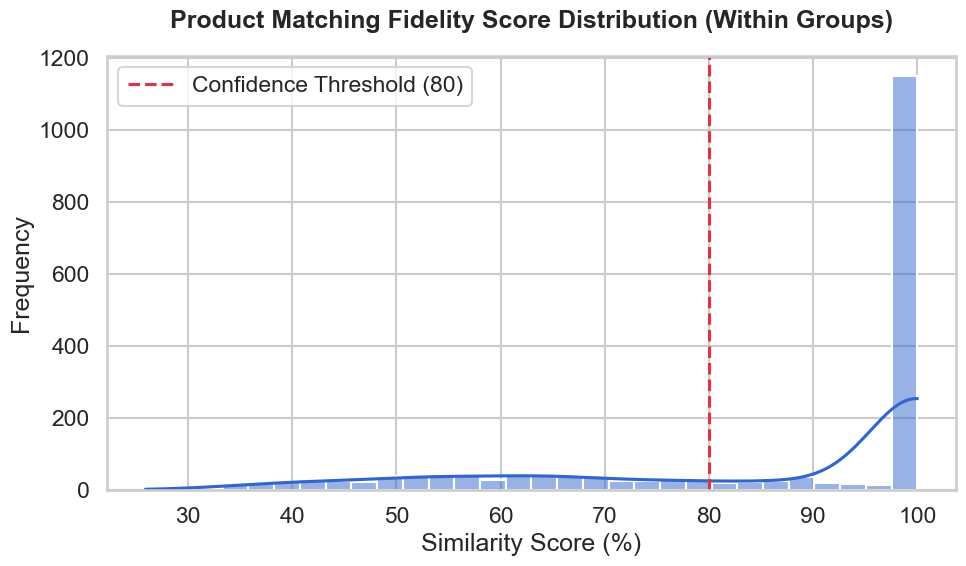

In [5]:
# Professional Matching Diagnostics
plt.figure(figsize=(10, 6))
# Sample pairs for distribution plot since we didn't store all scores
sample_matches = []
# Focus on pairs within the same match_key to show realistic potential match scores
keys = df['match_key'].unique()
for _ in range(2000):
   k = np.random.choice(keys)
   grp = df[df['match_key'] == k]
   if len(grp) >= 2:
       s1, s2 = grp['product_name_clean'].sample(2).tolist()
       sample_matches.append(fuzz.token_sort_ratio(s1, s2))

sns.histplot(sample_matches, bins=30, kde=True, color='#3366cc', edgecolor='white')
plt.axvline(80, color='#dc3545', linestyle='--', label='Confidence Threshold (80)')
plt.title("Product Matching Fidelity Score Distribution (Within Groups)", pad=20)
plt.xlabel("Similarity Score (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_matching_diagnostics.png', dpi=300)
plt.show()

## 4.5 — Export

In [6]:
out_cols = ['product_id','canonical_name','store_name','city','brand_clean',
            'category_normalized','price_clean','size_normalized','unit_normalized',
            'price_per_unit','scraped_at']
out_cols = [c for c in out_cols if c in matched_df.columns]
matched_df[out_cols].to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(matched_df):,} rows -> {OUTPUT_PATH}')
matched_df[out_cols].head(15)

Saved 11,561 rows -> D:\supermarket-pipeline\data\matched\matched_products.csv


,product_id,canonical_name,store_name,city,brand_clean,category_normalized,price_clean,size_normalized,unit_normalized,price_per_unit,scraped_at
10,P7A653E4D,olpers milk 1 ltr,Al-Fatah,Faisalabad,Olpers,Grocery Staples,320.0,1000.0,ml,0.320000,2026-03-08T20:17:01.040530
15,P1E5B9AAE,nestle water pure life 500 ml-carton,Al-Fatah,Faisalabad,Nestle,Grocery Staples,660.0,500.0,ml,1.320000,2026-03-08T20:17:01.040530
16,P1E5B9AAE,nestle water pure life 500 ml-carton,Al-Fatah,Faisalabad,Nestle,Grocery Staples,55.0,500.0,ml,0.110000,2026-03-08T20:17:01.040530
28,P7B17A4F4,nestle milk pak cream 200ml,Al-Fatah,Faisalabad,Nestle,Grocery Staples,220.0,200.0,ml,1.100000,2026-03-08T20:17:01.040530
29,PBF90C05C,nestle everyday milk powder sachet 13 gm,Al-Fatah,Faisalabad,Nestle,Grocery Staples,30.0,13.0,g,2.307692,2026-03-08T20:17:01.040530
40,P569FE1FB,dalda cooking oil pouch 1 ltr,Al-Fatah,Faisalabad,Dalda,Grocery Staples,580.0,1000.0,ml,0.580000,2026-03-08T20:17:01.040530
43,P1C6C3EB8,lays wavy bbq chips 30 gm,Al-Fatah,Faisalabad,Lays,Grocery Staples,50.0,30.0,g,1.666667,2026-03-08T20:17:01.040530
82,P1C6C3EB8,lays wavy bbq chips 30 gm,Al-Fatah,Faisalabad,Lays,Grocery Staples,70.0,45.0,g,1.555556,2026-03-08T20:17:01.040530
85,P54DC4665,lays chips french cheese 30 gm,Al-Fatah,Faisalabad,Lays,Grocery Staples,50.0,30.0,g,1.666667,2026-03-08T20:17:01.040530
88,P6FFF8949,sufi canola cooking oil pouch 1 ltr,Al-Fatah,Faisalabad,Sufi,Grocery Staples,575.0,1000.0,ml,0.575000,2026-03-08T20:17:01.040530
